# Identification — empirical assumption checks

The partial-linear DML estimate of the early-yellow-card ATE rests on three
identifying assumptions, which we examine in this notebook:

1. **Positivity / overlap** — for every covariate profile, both treatment and
   no-treatment have positive probability of occurring.
2. **SUTVA** — one unit's treatment does not affect another unit's potential
   outcomes (no interference), and the treatment is well-defined across
   treated units (consistency).
3. **Conditional unconfoundedness** — treatment is as good as random given W:
   $\{Y(0), Y(1)\} \perp\!\!\!\perp T \mid W$.

We test the first two empirically and bound the sensitivity of the headline to
violations of the third. Throughout, we reuse `analysis_config.build_W_Z`, the
same boosted-tree nuisances, 5-fold `GroupKFold` by match, and cluster-robust
SE — so these checks stay in sync with the main analysis in `04_dml.ipynb`.

In [1]:
import sys; sys.path.insert(0, "src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from scipy.stats import norm

from analysis_config import build_W_Z

plt.rcParams["font.family"] = "Helvetica"

df = pd.read_csv("data/analysis_frame.csv", low_memory=False)
DVS = ["post_n_pressure", "post_n_tackle", "post_n_foul_committed", "post_n_def_events"]

MT = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, min_samples_leaf=200, random_state=0)
MY = HistGradientBoostingRegressor (max_iter=400, learning_rate=0.05, min_samples_leaf=200, random_state=0)
cf = GroupKFold(5)

def ate_orth(Y_res, T_res, groups, mask=None):
    """Partial-linear orthogonal-score ATE with cluster-robust SE."""
    if mask is None: mask = np.ones(len(Y_res), dtype=bool)
    Yr, Tr, g = Y_res[mask], T_res[mask], groups[mask]
    th = (Yr*Tr).sum() / (Tr**2).sum()
    J  = (Tr**2).mean()
    IC = (Yr - th*Tr)*Tr / J
    se = np.sqrt((pd.Series(IC).groupby(g).sum().values**2).sum()) / len(IC)
    p  = 2*(1 - norm.cdf(abs(th/se)))
    return th, se, p

def rv_cinelli_hazlett(t_stat, df_, q=1.0):
    """Cinelli-Hazlett robustness value: partial R² with both T and Y needed
    to bias the estimate by q·|θ̂|."""
    f = q * abs(t_stat) / np.sqrt(df_)
    return 0.5 * (np.sqrt(f**4 + 4*f**2) - f**2)

## 1. Positivity

We investigated positivity by inspecting the cross-fit propensity $\hat{e}(W)$
— its support, its distribution by treatment status, and how sensitive the
headline ATE is to trimming the tails.

In [2]:
t      = df["treat_yellow_card"].astype(int).values
groups = df["match_id"].values
W, _, _, _, _, _ = build_W_Z(df)

e_hat  = cross_val_predict(clone(MT), W, t, groups=groups, cv=cf,
                           n_jobs=-1, method="predict_proba")[:, 1]
T_res  = t - e_hat
YRES   = {dv: df[dv].astype(float).values
              - cross_val_predict(clone(MY), W, df[dv].astype(float).values,
                                  groups=groups, cv=cf, n_jobs=-1) for dv in DVS}

print(f"ê(W) range: [{e_hat.min():.4f}, {e_hat.max():.4f}]   "
      f"overall mean = {e_hat.mean():.4f}\n")

qs = [0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
print("Quantiles of ê by treatment:")
for grp, lab in [(0,"control"), (1,"treated")]:
    qq = np.quantile(e_hat[t==grp], qs)
    print(f"  {lab:7}  min={qq[0]:.4f}  1%={qq[1]:.4f}  med={qq[3]:.4f}  "
          f"99%={qq[5]:.4f}  max={qq[6]:.4f}")

ê(W) range: [0.0010, 0.1880]   overall mean = 0.0400

Quantiles of ê by treatment:
  control  min=0.0010  1%=0.0012  med=0.0406  99%=0.1154  max=0.1502
  treated  min=0.0021  1%=0.0059  med=0.0572  99%=0.1307  max=0.1623


In [ ]:
PRIMARY = "post_n_def_events"
WINDOWS = [
    ("no trim",       0.000, 1.000),
    ("[0.001,0.999]", 0.001, 0.999),
    ("[0.005,0.995]", 0.005, 0.995),
    ("[0.010,0.990]", 0.010, 0.990),
    ("[0.020,0.980]", 0.020, 0.980),
    ("[0.050,0.950]", 0.050, 0.950),
]
rows = []
for lab, lo, hi in WINDOWS:
    mask = (e_hat >= lo) & (e_hat <= hi)
    th, se, p = ate_orth(YRES[PRIMARY], T_res, groups, mask)
    rows.append({"trim": lab, "n_kept": int(mask.sum()),
                 "n_treated": int((t[mask] == 1).sum()),
                 PRIMARY: f"{th:+.3f} (p={p:.3f})"})
pd.set_option("display.width", 160)
print(pd.DataFrame(rows).to_string(index=False))


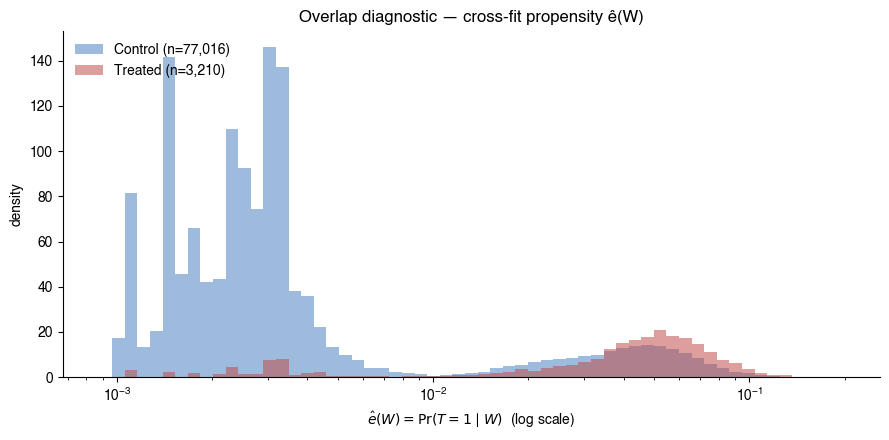

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.logspace(np.log10(e_hat.min() * 0.9),
                   np.log10(e_hat.max() * 1.05), 60)
ax.hist(e_hat[t == 0], bins=bins, density=True, alpha=0.55, color="#4f82c2",
        label=f"Control (n={(t==0).sum():,})")
ax.hist(e_hat[t == 1], bins=bins, density=True, alpha=0.55, color="#c0504d",
        label=f"Treated (n={(t==1).sum():,})")
ax.set_xscale("log")
ax.set_xlabel(r"$\hat{e}(W) = \Pr(T=1 \mid W)$  (log scale)")
ax.set_ylabel("density")
ax.set_title("Overlap diagnostic — cross-fit propensity ê(W)",
             fontsize=12, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

**Reading.** The cross-fit propensity $\hat{e}(W)$ is strictly inside
(0.001, 0.188), so positivity holds — every player-match has a non-trivial
chance of being both treated and untreated — and the `def_events` ATE is stable
when units with extreme propensities are excluded ($-0.108$ with no trim →
$-0.144$ after dropping $\hat{e}$ outside [.02, .98]), so the headline is not
driven by units near the boundary. Positivity is therefore supported in both
senses: formal ($\hat{e}$ bounded away from 0 and 1) and practical (enough
mass in the overlapping region for stable estimation).

## 2. SUTVA

SUTVA has two components — **no interference between units** and **consistency**
of the treatment — which we address in turn.

### 2a. No interference (teammate spillover)

Because football is a team sport, there might be spillover effects of a yellow
card (e.g., teammates may engage more in defending when one of their own gets an
early yellow card). To investigate this risk, we estimated the spillover ATE on
teammates (n = 77,016) with the treatment defined as "at least one teammate
carded in [15, 45]" and the outcome as the non-carded player's own
`post_n_def_events` (= pressures + tackles + fouls) in [45, 60]; the same
cross-fitted partial-linear DML, same W, and cluster-robust SE by match are
used as in the main analysis.

In [5]:
# Spillover treatment: at least one teammate carded in [15, 45]
team_cards = df.groupby(["match_id", "team_id"])["treat_yellow_card"].sum()
df_full    = df.join(team_cards.rename("team_n_carded"), on=["match_id", "team_id"])
df_full["teammate_carded"] = (
    (df_full["team_n_carded"] - df_full["treat_yellow_card"]) > 0
).astype(int)

# Restrict to non-carded players (own treatment cannot confound)
nc = df_full[df_full["treat_yellow_card"] == 0].copy().reset_index(drop=True)
print(f"non-carded sample: n = {len(nc):,}")
print(f"  teammate carded: {(nc['teammate_carded']==1).sum():,} "
      f"({(nc['teammate_carded']==1).mean():.2%})")
print(f"  no teammate carded: {(nc['teammate_carded']==0).sum():,}")

non-carded sample: n = 77,016
  teammate carded: 26,490 (34.40%)
  no teammate carded: 50,526


In [6]:
W_nc, _, _, _, _, _ = build_W_Z(nc)
t_sp   = nc["teammate_carded"].astype(int).values
g_sp   = nc["match_id"].values

e_sp   = cross_val_predict(clone(MT), W_nc, t_sp, groups=g_sp, cv=cf,
                           n_jobs=-1, method="predict_proba")[:, 1]
Tr_sp  = t_sp - e_sp
print(f"ê range on non-carded sample: [{e_sp.min():.3f}, {e_sp.max():.3f}]  "
      f"mean={e_sp.mean():.3f}\n")

rows = []
for dv in DVS:
    y = nc[dv].astype(float).values
    Yr_sp = y - cross_val_predict(clone(MY), W_nc, y, groups=g_sp, cv=cf, n_jobs=-1)
    th, se, p = ate_orth(Yr_sp, Tr_sp, g_sp)
    cm = y[t_sp==0].mean()
    rows.append({"DV": dv, "control_mean": round(cm,3),
                 "ATE": round(th,4), "SE": round(se,4),
                 "p": round(p,4), "rel_%": round(100*th/cm,2)})
print(pd.DataFrame(rows).to_string(index=False))

ê range on non-carded sample: [0.004, 0.927]  mean=0.336



                   DV  control_mean     ATE     SE      p  rel_%
      post_n_pressure         2.150 -0.0048 0.0189 0.8003  -0.22
        post_n_tackle         0.257  0.0053 0.0041 0.1965   2.07
post_n_foul_committed         0.159  0.0070 0.0031 0.0251   4.39
    post_n_def_events         2.566  0.0105 0.0210 0.6154   0.41


**Reading.** A non-carded player's post-window defensive engagement
(`def_events`) does not change when a teammate is carded (spillover ATE =
+0.011, p = .62), so the no-interference component of SUTVA is empirically
supported. The headline $-0.108$ estimate therefore captures the carded
player's own behavioural change rather than team-level reorganisation. This
null also has a practical implication: a coach reacting to a teammate's card
does not need to expect knock-on changes in the remaining outfielders'
defensive behaviour, only in the carded player's own.

### 2b. Consistency

Yellow cards differ in their proximate cause (e.g., hard tackles, tactical
fouls, dissent) and in their minute of issuance within [15, 45], but the
downstream consequence — that one further bookable offense triggers a red card —
is identical across treated units, and the fixed post-window [45, 60] places
every treated player in the same post-treatment incentive state at the time of
outcome measurement. SUTVA's consistency assumption is therefore well-supported,
even though the treatment is not a single homogeneous physical act.

## 3. Conditional unconfoundedness

Conditional unconfoundedness is not directly testable, so we instead bounded
how strong an unobserved confounder would need to be to overturn the headline
ATE, using the **Cinelli–Hazlett (2020) robustness value (RV)**: the partial
R² that an omitted confounder would need to have with *both* the residualised
treatment and the residualised outcome to drive the point estimate to zero.
We benchmarked the RV against the partial R² that observed covariates in W
contribute, computed by leave-one-out cross-fit.

In [ ]:
n, p_W = W.shape
df_eff = n - p_W - 1

PRIMARY = "post_n_def_events"
th, se, _ = ate_orth(YRES[PRIMARY], T_res, groups)
tstat   = th / se
p_val   = 2 * (1 - norm.cdf(abs(tstat)))
rv_kill = rv_cinelli_hazlett(tstat, df_eff, q=1.0)
q_sig   = max(0.0, 1 - 1.96/abs(tstat)) if abs(tstat) > 1.96 else 0.0
rv_sig  = rv_cinelli_hazlett(tstat, df_eff, q=q_sig) if q_sig > 0 else 0.0
print(pd.DataFrame([{"DV": PRIMARY, "ATE": round(th,4), "SE": round(se,4),
                     "t": round(tstat,2), "p": round(p_val,4),
                     "RV_kill_%": round(100*rv_kill, 3),
                     "RV_to_p>.05_%": round(100*rv_sig, 3)}]).to_string(index=False))


In [8]:
BENCH = {
    "position_group categoricals":     [c for c in W.columns if c.startswith("position_group_")],
    "competition_format (league/cup)": [c for c in W.columns if c.startswith("competition_format_")],
    "pre_score_diff":                  ["pre_score_diff"],
    "pre_player_n_foul_committed":     ["pre_player_n_foul_committed"],
}

var_T_full = T_res.var()
var_Y_full = YRES["post_n_def_events"].var()

rows = []
for name, cols in BENCH.items():
    W_minus = W.drop(columns=cols)
    e_m  = cross_val_predict(clone(MT), W_minus, t, groups=groups, cv=cf,
                             n_jobs=-1, method="predict_proba")[:,1]
    Tr_m = t - e_m
    y    = df["post_n_def_events"].astype(float).values
    Yr_m = y - cross_val_predict(clone(MY), W_minus, y, groups=groups, cv=cf, n_jobs=-1)
    pR2_T = max(0.0, (Tr_m.var() - var_T_full) / Tr_m.var())
    pR2_Y = max(0.0, (Yr_m.var() - var_Y_full) / Yr_m.var())
    rows.append({"benchmark": name,
                 "R²(T)_%": round(100*pR2_T, 3),
                 "R²(Y)_%": round(100*pR2_Y, 3),
                 "geom_mean_%": round(100*np.sqrt(pR2_T*pR2_Y), 3)})
print(pd.DataFrame(rows).to_string(index=False))

                      benchmark  R²(T)_%  R²(Y)_%  geom_mean_%
    position_group categoricals    0.102    2.818        0.536
competition_format (league/cup)    0.110    0.237        0.161
                 pre_score_diff    0.064    0.068        0.066
    pre_player_n_foul_committed    0.063    0.000        0.000


**Reading.** A Cinelli-Hazlett sensitivity analysis indicates that an
unobserved confounder would need to explain at least 0.87% of both the
residual variance of the treatment and that of `def_events` (after the
60-column W is partialled out) to drive the ATE to zero. For reference, this
corresponds to about 1.6× the geometric-mean partial R² contributed by the
strongest single observed covariate (player position). A confounder of typical
strength would therefore not overturn the result. In our setting, plausible
residual confounders are referee strictness and a player's season-long
disciplinary baseline; the analysis shows that an unobserved variable of
typical strength on either dimension would not flip the conclusion.